In [69]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter
from sympy.functions.combinatorial.numbers import totient
from tqdm.notebook import tqdm
import random
from matplotlib.patches import Wedge
from matplotlib.cm import ScalarMappable
phiCache = [0]
phiCache.extend([totient(k) for k in tqdm(range(1, int(1e5)))])

  0%|          | 0/99999 [00:00<?, ?it/s]

In [70]:
# Parameters
n = 200
num_alpha = 5000
fps = 24  # slow playback
alpha_max = 1  # short range
r_inner = 1.0     # Inner radius of the ring
r_outer = 1.3     # Outer radius of the ring

In [71]:
def phi(k, mode='totient'):
    if mode == 'totient':
        return phiCache[k]
    elif mode == 'random':
        rng = random.Random(k)  # seeded random
        return rng.randint(1, k - 1) if k > 1 else 1
    else:
        raise ValueError(f"Unknown phi mode: {mode}")

Precomputing vectors and sums:   0%|          | 0/5000 [00:00<?, ?it/s]

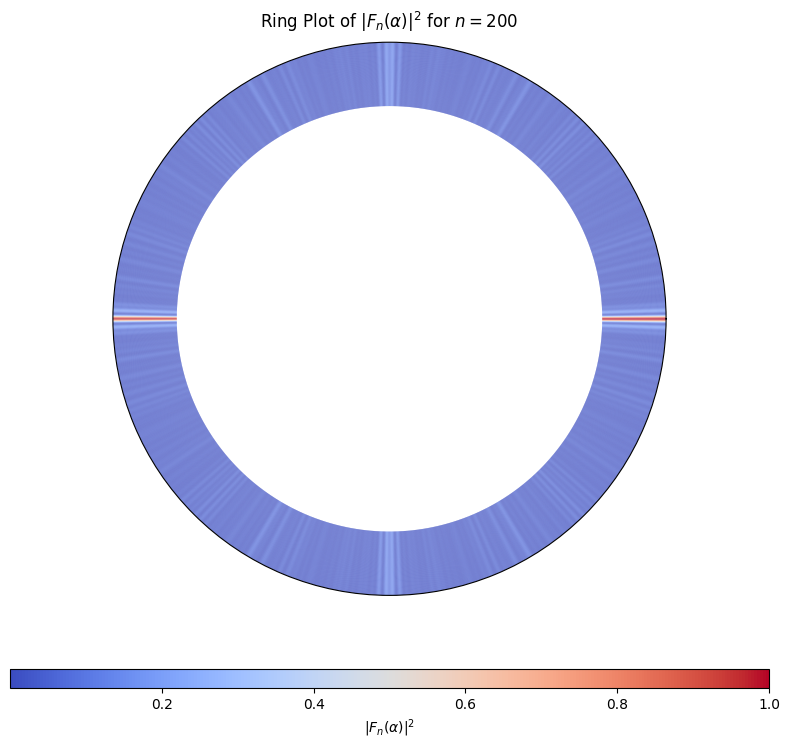

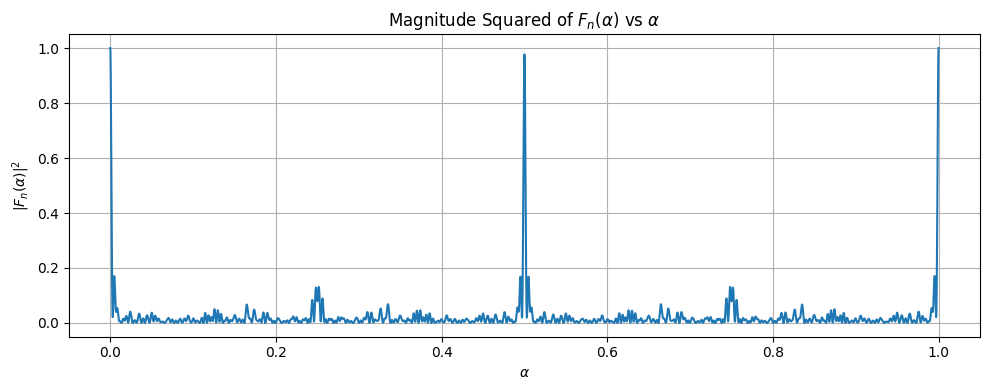

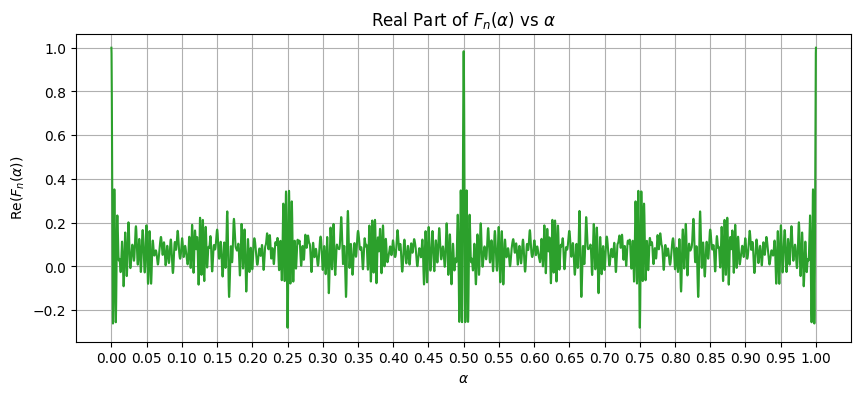

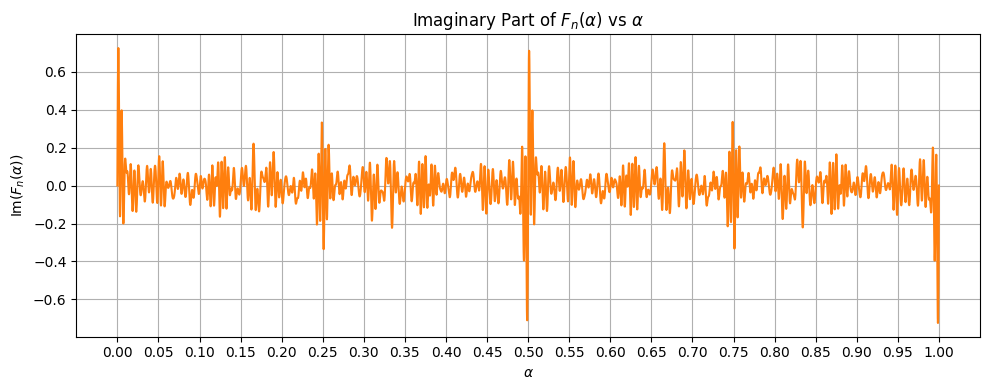

In [72]:
alphas = np.linspace(0, alpha_max, num_alpha)

# Precompute everything
all_sums = []
all_vectors = []

for alpha in tqdm(alphas, desc="Precomputing vectors and sums"):
    vectors = []
    for c in range(0, n - 1):
        phi_mode = 'totient'
        phi1 = phi(n + c, mode=phi_mode)
        phi2 = phi(n - c, mode=phi_mode)
        total_phi = int(phi1 + phi2)
        angle = 2 * np.pi * (2*n-2-total_phi) * alpha
        vectors.append(np.exp(1j * angle))
    path = np.cumsum(vectors)
    all_vectors.append(path)
    all_sums.append(path[-1])

# Magnitude squared
magnitudes_squared = np.abs(all_sums) ** 2
magnitudes_squared /= magnitudes_squared.max()
norm = plt.Normalize(magnitudes_squared.min(), magnitudes_squared.max())
cmap = plt.cm.coolwarm
colors = cmap(norm(magnitudes_squared))

# Plot using polar bars
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})
ax.set_xticks([])
ax.set_yticks([])
ax.set_ylim(0, r_outer)
ax.set_title(
    r"Ring Plot of $|F_n(\alpha)|^2$ for $n = {}$".format(n), va='bottom')

# Draw thick ring using polar bars
theta = np.linspace(0, 2 * np.pi, num_alpha, endpoint=False)
width = 2 * np.pi / num_alpha
radii = r_outer - r_inner

bars = ax.bar(theta, height=radii, width=width, bottom=r_inner,
              color=colors, edgecolor='none', align='edge')

# Colorbar
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', pad=0.1, aspect=40)
cbar.set_label(r"$|F_n(\alpha)|^2$")

plt.tight_layout()
plt.show()

# Cartesian plot: alpha vs |F_n(α)|^2
fig2, ax2 = plt.subplots(figsize=(10, 4))

ax2.plot(alphas, magnitudes_squared, color='tab:blue')
ax2.set_xlabel(r'$\alpha$')
ax2.set_ylabel(r'$|F_n(\alpha)|^2$')
ax2.set_title(r'Magnitude Squared of $F_n(\alpha)$ vs $\alpha$')
ax2.grid(True)

plt.tight_layout()
plt.show()

# Extract real and imaginary parts
real_parts = [z.real for z in all_sums]
imag_parts = [z.imag for z in all_sums]
xticks = np.arange(0, alpha_max + 0.001, 0.05)
# Normalize both to [-1, 1] range based on global max absolute value
max_val = max(np.max(np.abs(real_parts)), np.max(np.abs(imag_parts)))
real_parts = np.array(real_parts) / max_val
imag_parts = np.array(imag_parts) / max_val

# Create ticks at every 0.05 in alpha range
xticks = np.arange(0, alpha_max + 0.001, 0.05)

# Plot: Real part vs alpha
fig3, ax3 = plt.subplots(figsize=(10, 4))
ax3.plot(alphas, real_parts, color='tab:green')
ax3.set_xlabel(r'$\alpha$')
ax3.set_ylabel(r'Re$(F_n(\alpha))$')
ax3.set_title(r'Real Part of $F_n(\alpha)$ vs $\alpha$')
ax3.set_xticks(xticks)
ax3.grid(True)

# Plot: Imaginary part vs alpha
fig4, ax4 = plt.subplots(figsize=(10, 4))
ax4.plot(alphas, imag_parts, color='tab:orange')
ax4.set_xlabel(r'$\alpha$')
ax4.set_ylabel(r'Im$(F_n(\alpha))$')
ax4.set_title(r'Imaginary Part of $F_n(\alpha)$ vs $\alpha$')
ax4.set_xticks(xticks)
ax4.grid(True)

plt.tight_layout()
plt.show()

In [73]:
# # Plot setup
# fig, ax = plt.subplots(figsize=(8, 8))
# ax.set_aspect('equal')
# ax.grid(True)
# ax.set_xlabel('Re')
# ax.set_ylabel('Im')

# # Set limits
# real_vals = [z.real for z in all_sums]
# imag_vals = [z.imag for z in all_sums]
# margin = 2
# ax.set_xlim(min(real_vals) - margin, max(real_vals) + margin)
# ax.set_ylim(min(imag_vals) - margin, max(imag_vals) + margin)

# # Plot elements
# (sum_point,) = ax.plot([], [], 'ro', markersize=10)
# (path_line,) = ax.plot([], [], 'b-', lw=2, alpha=0.6)
# (trail_line,) = ax.plot([], [], 'r--', lw=1.5, alpha=0.6)

# pbar = tqdm(total=len(alphas), desc="Rendering frames", position=0)


# def update(frame):
#     vecs = all_vectors[frame]
#     z = all_sums[frame]

#     path_line.set_data(vecs.real, vecs.imag)
#     sum_point.set_data([z.real], [z.imag])

#     # Trail of sum positions
#     trail = all_sums[:frame + 1]
#     trail_x = [pt.real for pt in trail]
#     trail_y = [pt.imag for pt in trail]
#     trail_line.set_data(trail_x, trail_y)

#     ax.set_title(f"N = {n}; α = {alphas[frame]:.5f}")
#     pbar.update(1)
#     return sum_point, path_line, trail_line


# # Animation
# anim = FuncAnimation(fig, update, frames=len(
#     alphas), interval=1000 // fps, blit=True)

# # Save
# writer = FFMpegWriter(fps=fps)
# anim.save(f"random_sum_zoomed_animation_{n}.mp4", writer=writer)

# plt.show()
# pbar.close()